# Goal and Work Summary

**Goal**: Build and evaluate a full-image semantic segmentation pipeline to detect defects in green rough oak planks (Background, BlackRot, Knot, Stain). The notebook focuses on cleaning/structuring the data, training a ResNet34‑UNet model, and producing reliable test‑set metrics and visual diagnostics.

## Workflow Stages and Rationale

**Stage 1 — Data audit and class normalization**
- We start by scanning the raw line‑scan dataset to quantify available samples and class masks.
- Duplicate or inconsistent defect names are normalized to a single class name to avoid label fragmentation.
- These steps are automated with custom helpers in `notebooks/functions` to ensure repeatability.

**Why this choice**: A consistent class taxonomy is required for stable training and honest evaluation; automated utilities reduce manual errors.

**Stage 2 — Filtering rare classes**
- Defect classes with very few masks are moved out to reduce class imbalance and training noise.
- The threshold is explicit so we can revisit it as more data arrives.

**Why this choice**: Extremely low‑frequency classes destabilize training and can dominate loss scaling for segmentation tasks.

**Stage 3 — Reorganization and validation**
- The dataset is reorganized into a clean structure with image/mask alignment.
- We validate integrity (missing masks, bad samples) and move invalid items to a filtered area.

**Why this choice**: Clean data organization simplifies dataloading and prevents silent misalignment during training.

**Stage 4 — Mask composition and splits**
- Separate defect masks are merged into a single multi‑class mask per image.
- Train/val/test splits are persisted to JSON for consistent experiment reuse.

**Why this choice**: Multi‑class masks match the model output and preserve consistent evaluation across runs.

**Stage 5 — Full‑image dataset + augmentations**
- A full‑image dataset class is defined with Albumentations transforms for robust training.
- Normalization uses ImageNet statistics to match the ResNet34 encoder initialization.

**Why this choice**: Full images preserve spatial context; augmentations reduce overfitting; ImageNet stats align with encoder priors.

**Stage 6 — Model training and checkpointing**
- We train a UNet with ResNet34 encoder using CrossEntropy loss.
- TensorBoard logs track loss and IoU; checkpoints are saved for reproducibility.

**Why this choice**: UNet is a strong baseline for segmentation; ResNet34 balances capacity and speed.

**Stage 7 — Best‑model selection and test evaluation**
- The best checkpoint is selected by validation IoU and saved to the models folder.
- The model is reloaded for test‑set inference to avoid training‑state leakage.
- Metrics include mean IoU, ROC curves (one‑vs‑rest), F1, accuracy, and a percentage confusion matrix.

**Why this choice**: Validation‑based selection provides a fair model for final reporting; multiple metrics reveal different failure modes.

## Custom Functions Used

We rely on project‑specific helpers (in `notebooks/functions`) to standardize data processing:
- `analyze_dataset`, `reorganize_dataset`, `validate_dataset`, `move_invalid_samples`
- `create_combined_masks`, `create_train_val_split`
- `rename_defect_files`, `filter_classes_by_mask_count`

These encapsulate repeatable steps and document the intended data workflow.

## References (Libraries)

| Library | Purpose | Notes | Link |
| --- | --- | --- | --- |
| PyTorch | Training, inference, dataloaders | Core deep learning framework and CUDA support | https://pytorch.org/ |
| segmentation_models_pytorch | UNet + encoder zoo | Provides ResNet34‑UNet and pretrained encoders | https://github.com/qubvel/segmentation_models.pytorch |
| Albumentations | Augmentations + normalization | Fast, flexible image transforms for segmentation | https://albumentations.ai/ |
| OpenCV | Image utilities | Used for file I/O and preprocessing support | https://opencv.org/ |
| NumPy | Array ops | Efficient tensor/array manipulation | https://numpy.org/ |
| Pillow | Image reading | Handles TIFF/PNG image loading | https://python-pillow.org/ |
| scikit‑learn | Metrics | ROC, F1, accuracy, confusion matrix | https://scikit-learn.org/ |
| Matplotlib | Plotting | Curves and confusion matrix visualization | https://matplotlib.org/ |
| TensorBoard | Logging | Visual tracking of training metrics | https://www.tensorflow.org/tensorboard |


## Goal and Outline

To improve our defect detection on green rough oak planks

## Current Detection Configuration

We currently use traditional computer vision methods to capture color images, 3D data, and Laser images to give a detailed view of the board. Defects are detected by binarizing these images with filters and parameters to outline detects in the wood and make model decisions 

## Method of data collection

Board images are collected through a line scan camera system created by EBI. This is our 

In [2]:
# Import Libraries
from functions.model_tools import (analyze_dataset,
                                   reorganize_dataset,
                                   validate_dataset,
                                   move_invalid_samples,
                                   create_combined_masks,
                                   create_train_val_split
)
from functions.rename_files import rename_defect_files
from functions.filter_by_mask_count import filter_classes_by_mask_count
import segmentation_models_pytorch as smp
from torch.utils.tensorboard import SummaryWriter

In [2]:
# Analyze the Dataset
RAW_DATA_FOLDER = '../data/raw-data'
stats = analyze_dataset(RAW_DATA_FOLDER)

DATASET ANALYSIS
Total files: 6201

Color images (_Col.tif): 562

Mask classes found:
  - BlackRot: 691 masks
  - Knot: 871 masks
  - Stain: 143 masks

Other files (ignored): 3934
  Examples: ['1-29-26_3.28.48.206_Bot_3DRaw.tif', '1-29-26_3.28.48.206_Bot_Depth.tif', '1-29-26_3.28.48.206_Bot_Elevation.tif', '1-29-26_3.28.48.206_Bot_Lum.tif', '1-29-26_3.28.48.206_Bot_Scatter.tif']


**First Observations**

We have duplicate class names, we will merge the classes together under one class.

In [14]:
# Rename Defect Files
rename_defect_files(RAW_DATA_FOLDER)

Renamed: 1-29-26_3.28.48.206_Bot_Col_Bin_Black_Rot.tif → 1-29-26_3.28.48.206_Bot_Col_Bin_BlackRot.tif
Renamed: 1-29-26_3.28.48.206_Bot_Lum_Bin_Black_Rot.tif → 1-29-26_3.28.48.206_Bot_Lum_Bin_BlackRot.tif
Renamed: 1-29-26_3.28.48.206_Top_Col_Bin_Black_Rot.tif → 1-29-26_3.28.48.206_Top_Col_Bin_BlackRot.tif
Renamed: 1-29-26_3.28.48.206_Top_Lum_Bin_Black_Rot.tif → 1-29-26_3.28.48.206_Top_Lum_Bin_BlackRot.tif
Renamed: 1-29-26_3.29.08.459_Bot_Col_Bin_Black_Rot.tif → 1-29-26_3.29.08.459_Bot_Col_Bin_BlackRot.tif
Renamed: 1-29-26_3.29.08.459_Bot_Lum_Bin_Black_Rot.tif → 1-29-26_3.29.08.459_Bot_Lum_Bin_BlackRot.tif
Renamed: 1-29-26_3.29.20.751_Bot_Col_Bin_Black_Rot.tif → 1-29-26_3.29.20.751_Bot_Col_Bin_BlackRot.tif
Renamed: 1-29-26_3.29.20.751_Bot_Lum_Bin_Black_Rot.tif → 1-29-26_3.29.20.751_Bot_Lum_Bin_BlackRot.tif
Renamed: 1-29-26_4.14.23.570_Bot_Col_Bin_Black_Rot.tif → 1-29-26_4.14.23.570_Bot_Col_Bin_BlackRot.tif
Renamed: 1-29-26_4.14.23.570_Bot_Lum_Bin_Black_Rot.tif → 1-29-26_4.14.23.570_Bot_L

{'1-29-26_3.28.48.206_Bot_Col_Bin_Black_Rot.tif': '1-29-26_3.28.48.206_Bot_Col_Bin_BlackRot.tif',
 '1-29-26_3.28.48.206_Bot_Lum_Bin_Black_Rot.tif': '1-29-26_3.28.48.206_Bot_Lum_Bin_BlackRot.tif',
 '1-29-26_3.28.48.206_Top_Col_Bin_Black_Rot.tif': '1-29-26_3.28.48.206_Top_Col_Bin_BlackRot.tif',
 '1-29-26_3.28.48.206_Top_Lum_Bin_Black_Rot.tif': '1-29-26_3.28.48.206_Top_Lum_Bin_BlackRot.tif',
 '1-29-26_3.29.08.459_Bot_Col_Bin_Black_Rot.tif': '1-29-26_3.29.08.459_Bot_Col_Bin_BlackRot.tif',
 '1-29-26_3.29.08.459_Bot_Lum_Bin_Black_Rot.tif': '1-29-26_3.29.08.459_Bot_Lum_Bin_BlackRot.tif',
 '1-29-26_3.29.20.751_Bot_Col_Bin_Black_Rot.tif': '1-29-26_3.29.20.751_Bot_Col_Bin_BlackRot.tif',
 '1-29-26_3.29.20.751_Bot_Lum_Bin_Black_Rot.tif': '1-29-26_3.29.20.751_Bot_Lum_Bin_BlackRot.tif',
 '1-29-26_4.14.23.570_Bot_Col_Bin_Black_Rot.tif': '1-29-26_4.14.23.570_Bot_Col_Bin_BlackRot.tif',
 '1-29-26_4.14.23.570_Bot_Lum_Bin_Black_Rot.tif': '1-29-26_4.14.23.570_Bot_Lum_Bin_BlackRot.tif',
 '1-29-26_4.14.23.57

In [15]:
result = filter_classes_by_mask_count(
    source_folder=RAW_DATA_FOLDER,
    mask_threshold=50,  
    output_folder="../data/filtered-data"  
)

FILTERING CLASSES WITH < 50 MASKS

Classes MOVED (< 50 masks):
  - Heartwood: 2 masks → moved to filtered-data/
  - StainMinor: 30 masks → moved to filtered-data/
  - YellowRot: 38 masks → moved to filtered-data/

Classes KEPT (>= 50 masks):
  - BlackRot: 691 masks
  - Knot: 871 masks
  - Stain: 143 masks

Total files moved: 70
Filtered data location: ../data/filtered-data


In [3]:
# Reorganize Dataset into Class Folders

source = RAW_DATA_FOLDER
output = "../data/organized-data"
reorganize_dataset(source, output)

Cleared existing folder: ../data/organized-data
REORGANIZATION COMPLETE
Images copied: 562

Masks by class:
  BlackRot: 347
  Knot: 435
  Stain: 72


{'images': 562,
 'masks': defaultdict(int, {'BlackRot': 347, 'Knot': 435, 'Stain': 72})}

In [1]:
# Validate the Reorganized Dataset
organized_folder = "../data/organized-data"
valid_samples, issues = validate_dataset(organized_folder)

NameError: name 'validate_dataset' is not defined

In [3]:
# Move invalid samples
move_invalid_samples(organized_folder, issues, output_folder="../data/filtered-data")

Moved image: 10-27-25_7.46.42.126_Top_Col.tif
Moved 1 files to ../data/filtered-data


1

In [2]:
organized_folder = "../data/organized-data"
class_mapping = create_combined_masks(organized_folder)

CREATING COMBINED MASKS
Class mapping:
  0: Background
  1: BlackRot
  2: Knot
  3: Stain



Processing: 100%|██████████| 561/561 [01:15<00:00,  7.41it/s]


Combined masks saved to: ../data/organized-data/combined_masks


In [3]:
# Usage
organized_folder = "../data/organized-data"
split_info = create_train_val_split(organized_folder, val_split=0.16, test_split=0.2)

TRAIN/VAL/TEST SPLIT
Train samples: 376
Val samples:   72
Test samples:  113
Split saved to: ../data/organized-data/split.json


In [5]:
from pathlib import Path
import cv2
import numpy as np
from PIL import Image
import json
import torch
from torch.utils.data import Dataset
import albumentations as A
from albumentations.pytorch import ToTensorV2

class FullImageSegmentationDataset(Dataset):
    def __init__(self, data_root, split='train', transform=None):
        self.data_root = Path(data_root)
        self.split = split
        self.transform = transform

        split_file = self.data_root / "split.json"
        with open(split_file, 'r') as f:
            split_info = json.load(f)
        self.image_ids = split_info[split]

        self.images_dir = self.data_root / "images"
        self.masks_dir = self.data_root / "combined_masks"

        print(f"Loaded {split} dataset: {len(self.image_ids)} images (full image mode)")

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_path = self.images_dir / f"{img_id}_Col.tif"
        mask_path = self.masks_dir / f"{img_id}_mask.png"
        image = np.array(Image.open(img_path).convert('RGB'))
        mask = np.array(Image.open(mask_path))

        if self.transform:
            transformed = self.transform(image=image, mask=mask)
            image = transformed['image']
            mask = transformed['mask']

        return image, mask.long()

# Full-image augmentations 
def get_training_augmentation_full():
    return A.Compose([
        A.Resize(512, 512),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5),
        A.OneOf([A.RandomBrightnessContrast(p=1), A.RandomGamma(p=1)], p=0.3),
        A.OneOf([A.GaussNoise(p=1), A.GaussianBlur(p=1)], p=0.2),
        A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
        ToTensorV2()
    ])

def get_validation_augmentation_full():
    return A.Compose([
        A.Resize(512, 512),
        A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
        ToTensorV2()
    ])

def create_dataloaders_full(data_root, batch_size=2, num_workers=4):
    train_dataset = FullImageSegmentationDataset(
        data_root=data_root, split='train',
        transform=get_training_augmentation_full()
    )
    val_dataset = FullImageSegmentationDataset(
        data_root=data_root, split='val',
        transform=get_validation_augmentation_full()
    )
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    return train_loader, val_loader

/home/vscode/.local/lib/python3.10/site-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error [Errno -3] Temporary failure in name resolution>
  data = fetch_version_info()


In [5]:
# Use 224px patches and 50% overlap (stride=112). adjust batch sizes to fit GPU.
train_loader, val_loader = create_dataloaders_full(
    data_root="../data/organized-data",
    batch_size=32,          # adjust to GPU memory
    num_workers=4
)

#num_classes = len(class_mapping)  # or set explicitly
num_classes = 4  # set explicitly based on your dataset
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=num_classes
).to("cuda")



/home/vscode/.local/lib/python3.10/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Loaded train dataset: 376 images (full image mode)
Loaded val dataset: 72 images (full image mode)


### Model Training

In [6]:
print("CUDA available:", torch.cuda.is_available())
print("Current device:", torch.cuda.current_device())
print("Device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

CUDA available: True
Current device: 0
Device name: NVIDIA GeForce RTX 4070 Ti


In [7]:
print("torch.cuda.is_available():", torch.cuda.is_available())
print("torch.version.cuda:", torch.version.cuda)
print("torch.backends.cudnn.version():", torch.backends.cudnn.version())
print("Device:", torch.device("cuda" if torch.cuda.is_available() else "cpu"))

torch.cuda.is_available(): True
torch.version.cuda: 12.6
torch.backends.cudnn.version(): 91002
Device: cuda


In [ ]:
import torch
import torch.nn as nn
from torch.optim import Adam
from pathlib import Path
import json

# Setup training
device = "cuda" if torch.cuda.is_available() else "cpu"
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=1e-3)
num_epochs = 50
checkpoint_dir = Path("../checkpoints/UNet_FullImage") # Change this to the model name
checkpoint_dir.mkdir(exist_ok=True)

# Training history
history = {
    'train_loss': [],
    'val_loss': [],
    'val_iou': []
}

def compute_iou(pred, target, num_classes):
    """Compute per-class IoU (Intersection over Union)."""
    ious = []
    for cls in range(num_classes):
        pred_mask = (pred == cls)
        target_mask = (target == cls)
        intersection = (pred_mask & target_mask).sum().float()
        union = (pred_mask | target_mask).sum().float()
        iou = intersection / (union + 1e-6)
        ious.append(iou.item())
    return np.mean(ious)

def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0.0
    num_batches = 0
    
    for img_patch, mask_patch in train_loader:
        img_patch = img_patch.to(device)
        mask_patch = mask_patch.to(device)
        
        # Forward
        logits = model(img_patch)  # [B, C, H, W]
        loss = criterion(logits, mask_patch)  # [B, H, W]
        
        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        num_batches += 1
    
    return total_loss / num_batches

def validate(model, val_loader, criterion, device, num_classes):
    """Validate model."""
    model.eval()
    total_loss = 0.0
    total_iou = 0.0
    num_batches = 0
    
    with torch.no_grad():
        for img_patch, mask_patch in val_loader:
            img_patch = img_patch.to(device)
            mask_patch = mask_patch.to(device)
            
            logits = model(img_patch)
            loss = criterion(logits, mask_patch)
            pred = torch.argmax(logits, dim=1)
            
            iou = compute_iou(pred, mask_patch, num_classes)
            
            total_loss += loss.item()
            total_iou += iou
            num_batches += 1
    
    return total_loss / num_batches, total_iou / num_batches

# Create a TensorBoard writer
writer = SummaryWriter(log_dir="../logs/tensorboard/ResNet34_Unet_FullImage")

print("Using device:", device)
print("Model device:", next(model.parameters()).device)

# Training loop
for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_iou = validate(model, val_loader, criterion, device, num_classes)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_iou'].append(val_iou)
    
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val IoU: {val_iou:.4f}")
    
    # Log to TensorBoard
    writer.add_scalar("Loss/Train", train_loss, epoch)
    writer.add_scalar("Loss/Val", val_loss, epoch)
    writer.add_scalar("IoU/Val", val_iou, epoch)


    # Save checkpoint every 5 epochs
    if (epoch + 1) % 5 == 0:
        ckpt_path = checkpoint_dir / f"model_epoch_{epoch+1}.pt"
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_iou': val_iou,
        }, ckpt_path)
        print(f"  → Checkpoint saved: {ckpt_path}")

# Save final history
history_path = checkpoint_dir / "training_history.json"
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)
print(f"\nTraining complete. History saved to {history_path}")

Using device: cuda
Model device: cuda:0
Epoch 1/50 | Train Loss: 0.8455 | Val Loss: 34.4631 | Val IoU: 0.1413
Epoch 2/50 | Train Loss: 0.4276 | Val Loss: 1.3746 | Val IoU: 0.2200
Epoch 3/50 | Train Loss: 0.3487 | Val Loss: 0.3374 | Val IoU: 0.3386
Epoch 4/50 | Train Loss: 0.3351 | Val Loss: 0.2689 | Val IoU: 0.3353
Epoch 5/50 | Train Loss: 0.3223 | Val Loss: 0.3059 | Val IoU: 0.3323
  → Checkpoint saved: ../checkpoints/model_epoch_5.pt
Epoch 6/50 | Train Loss: 0.3092 | Val Loss: 0.2196 | Val IoU: 0.3738
Epoch 7/50 | Train Loss: 0.3135 | Val Loss: 0.2405 | Val IoU: 0.3593
Epoch 8/50 | Train Loss: 0.3116 | Val Loss: 0.2807 | Val IoU: 0.3242
Epoch 9/50 | Train Loss: 0.3218 | Val Loss: 1.5870 | Val IoU: 0.1147
Epoch 10/50 | Train Loss: 0.3037 | Val Loss: 0.2853 | Val IoU: 0.3524
  → Checkpoint saved: ../checkpoints/model_epoch_10.pt
Epoch 11/50 | Train Loss: 0.3043 | Val Loss: 0.2442 | Val IoU: 0.3450
Epoch 12/50 | Train Loss: 0.2945 | Val Loss: 0.2135 | Val IoU: 0.3755
Epoch 13/50 | Train

In [ ]:
# Save best model epoch

best_model = 

In [ ]:
from pathlib import Path
import torch

num_classes = 4
ckpt_dir = Path("../checkpoints/UNet_FullImage") # Change this to the model name
models_dir = Path("../models/UNet_FullImage") # Change this to the model name
models_dir.mkdir(exist_ok=True)

best_ckpt = None
best_val_iou = -1.0

for ckpt_path in ckpt_dir.glob("model_epoch_*.pt"):
    ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    val_iou = ckpt.get("val_iou", -1.0)
    if val_iou > best_val_iou:
        best_val_iou = val_iou
        best_ckpt = ckpt

if best_ckpt is None:
    raise FileNotFoundError("No checkpoints found in ../checkpoints")

best_model_path = models_dir / "best_model.pt"
torch.save(
    {
        "model_state_dict": best_ckpt["model_state_dict"],
        "val_iou": best_val_iou,
        "epoch": best_ckpt.get("epoch", None),
        "num_classes": num_classes,
    },
    best_model_path,
)

print(f"Saved best model to {best_model_path} (val_iou={best_val_iou:.4f})")

Saved best model to ../models/best_model.pt (val_iou=0.4497)


In [6]:
# Create test loader
test_dataset = FullImageSegmentationDataset(
    data_root="../data/organized-data",
    split="test",
    transform=get_validation_augmentation_full()
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=8, shuffle=False, num_workers=4, pin_memory=True
)

Loaded test dataset: 113 images (full image mode)


In [8]:
import segmentation_models_pytorch as smp

device = "cuda" if torch.cuda.is_available() else "cpu"

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,  # weights already in state_dict
    in_channels=3,
    classes=num_classes
).to(device)

ckpt = torch.load(best_model_path, map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

print(f"Loaded best model (epoch={ckpt.get('epoch')}, val_iou={ckpt.get('val_iou'):.4f})")

Loaded best model (epoch=25, val_iou=0.4497)


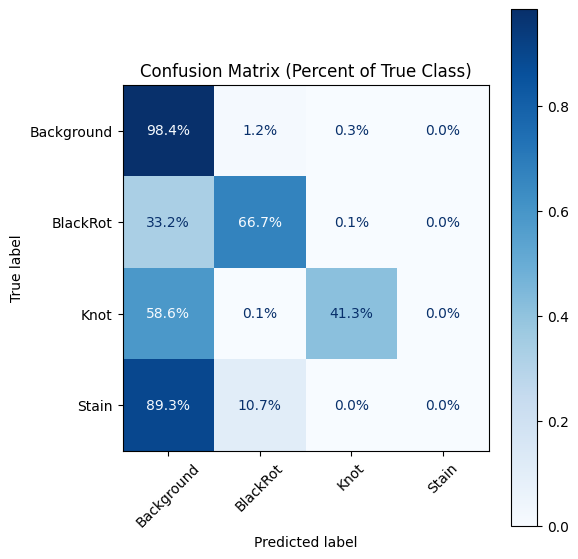

Accuracy: 0.9013
F1 per class:
  Background: 0.9461
  BlackRot: 0.7402
  Knot: 0.4759
  Stain: 0.0000
F1 Macro: 0.5405
IoU per class:
  Background: 0.8977
  BlackRot: 0.5876
  Knot: 0.3123
  Stain: 0.0000
Mean IoU (excl background): 0.2999


/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


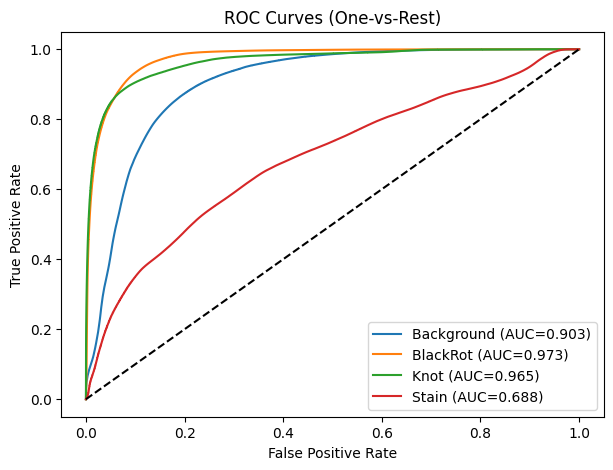

In [11]:
import numpy as np
import torch
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# class names (update if you change mapping)
class_names = ["Background", "BlackRot", "Knot", "Stain"]

all_preds = []
all_targets = []
all_probs = []

with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(device)
        masks = masks.to(device)

        logits = model(images)  # [B,C,H,W]
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.append(preds.cpu().numpy().reshape(-1))
        all_targets.append(masks.cpu().numpy().reshape(-1))
        all_probs.append(probs.cpu().numpy().transpose(0, 2, 3, 1).reshape(-1, num_classes))

all_preds = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)
all_probs = np.concatenate(all_probs)

# Confusion matrix (percentages by true class)
cm = confusion_matrix(all_targets, all_preds, labels=list(range(num_classes)))
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
cm_norm = np.nan_to_num(cm_norm)  # handle any empty classes

disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", values_format=".1%", colorbar=True, xticks_rotation=45)
plt.title("Confusion Matrix (Percent of True Class)")
plt.tight_layout()
plt.show()

# Accuracy (pixel-level)
acc = accuracy_score(all_targets, all_preds)
print(f"Accuracy: {acc:.4f}")

# F1 scores
f1_per_class = f1_score(all_targets, all_preds, labels=list(range(num_classes)), average=None)
f1_macro = f1_score(all_targets, all_preds, labels=list(range(num_classes)), average="macro")

print("F1 per class:")
for i, f1 in enumerate(f1_per_class):
    print(f"  {class_names[i]}: {f1:.4f}")
print(f"F1 Macro: {f1_macro:.4f}")

# IoU per class + mean IoU
intersection = np.diag(cm).astype(np.float32)
union = cm.sum(axis=0) + cm.sum(axis=1) - intersection
iou_per_class = np.divide(intersection, union, out=np.zeros_like(intersection), where=union != 0)

print("IoU per class:")
for i, iou in enumerate(iou_per_class):
    print(f"  {class_names[i]}: {iou:.4f}")

include_background = False
if include_background:
    mean_iou = iou_per_class.mean()
else:
    mean_iou = iou_per_class[1:].mean()  # skip background
print(f"Mean IoU ({'incl' if include_background else 'excl'} background): {mean_iou:.4f}")

# ROC curves (one-vs-rest)
plt.figure(figsize=(7, 5))
for c in range(num_classes):
    y_true_bin = (all_targets == c).astype(int)
    y_score = all_probs[:, c]

    # skip if class absent
    if y_true_bin.sum() == 0:
        print(f"ROC skipped: {class_names[c]} (no positives in test set)")
        continue

    fpr, tpr, _ = roc_curve(y_true_bin, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_names[c]} (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest)")
plt.legend()
plt.show()